# 中草药图片分类

为了帮助人们更好地理解和识别不同的中草药植物，通过对中草药图片进行分类，可以将相似的植物归类在一起，方便人们进行比较和研究。

## 1. 数据集处理

### 1.1 导入有关库

In [1]:
import mindspore as ms
import numpy as np
import mindspore.dataset as ds
import mindspore.dataset.vision as vision
from mindspore.dataset.vision import Inter
from mindspore import nn, ops
import os
# import download
import stat
import matplotlib.pyplot as plt
import numpy as np


Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 801 ('font.family: sans-serif')
Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 802 ('font.sans-serif: SimHei')


上传后导入自建数据集

数据集为中草药图片，从互联网中收集，大小不等，均为 .jgp 格式

手动划分为训练集和验证集，数据集根目录下有 train 和 val 两个文件夹

训练集和验证集都有五种类别，分别是 baihe（百合），dangshen（党参），gouqi（枸杞），huaihua（槐花），jinyinhua（金银花）

数据集共有 902 张，验证集每类 30 张共 150 张，训练集每类分别为 150 张，160 张，155 张，137 张，150 张，共 752 张

In [3]:
data_dir = "/home/jovyan/work/datasets/68959a7ee65e3f13b7427a7e-momodel/" # 数据集根目录
batch_size = 6 # 批量大小
image_size = [320, 320] # 训练图像空间大小
num_classes = 5 # 种类数
classes = os.listdir(data_dir + 'train')
print(batch_size,image_size,num_classes)


6 [320, 320] 5


### 1.2 数据集展示

训练集和验证集中分别展示每一类图片的第一张图片。

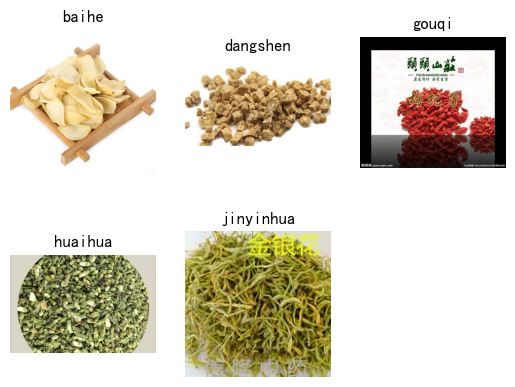

In [4]:
filelist_train = []
path_train = data_dir + 'train'
for filename in os.listdir(path_train):
    path = os.path.join(path_train,filename)
    for filename1 in os.listdir(path):
        filepath = os.path.join(path,filename1)
        filelist_train.append(filepath)
        break
plt.figure()
i = 0
for filepath in filelist_train:
    i += 1
    img = plt.imread(filepath)
    plt.subplot(2,3,i)
    plt.title(f"{classes[i-1]}")
    plt.imshow(img)
    plt.axis("off")
plt.show()


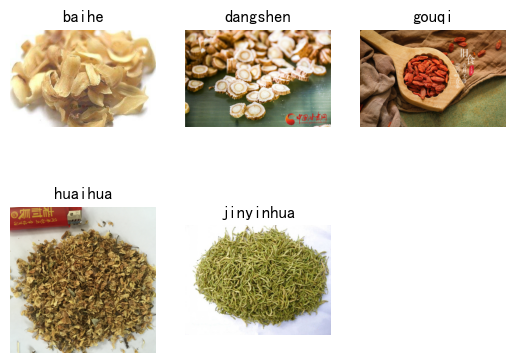

In [5]:
filelist_val = []
path_val = data_dir + 'val'
for filename in os.listdir(path_val):
    path = os.path.join(path_val,filename)
    for filename1 in os.listdir(path):
        filepath = os.path.join(path,filename1)
        filelist_val.append(filepath)
        break
classes = os.listdir(path_val)
plt.figure()
i = 0
for filepath in filelist_val:
    i += 1
    img = plt.imread(filepath)
    plt.subplot(2,3,i)
    plt.title(f"{classes[i-1]}")
    plt.imshow(img)
    plt.axis("off")
plt.show()


## 2. 数据集分析和可视化

### 2.1 生成训练和验证数据集

对图像做一些调整和翻转，对数据集大小 resize 为 320 * 320，并进行归一化。

*   dataset_dir：数据集根目录
*   usage：值可以为 "train" 或 "val"，表示是构建训练集还是验证集
*   resize：处理后的数据集图像大小，本程序中设置为 320
*   batch_size：批量大小
*   return：返回处理好的数据集
*   shuffle：shuffle=True 表示需要混洗数据集，即随机在其中取数据而不是按照顺序

In [6]:
def create_dataset(dataset_dir, usage, resize, batch_size):
    data_set = ds.ImageFolderDataset(dataset_dir=dataset_dir+usage,
                                 decode=True,
                                 shuffle=True,
                                 extensions=[".jpg"])
    trans = [] #需要做的变化的集合

    if usage == "train":
        trans += [
            vision.Resize(resize),
            vision.RandomColorAdjust(brightness=(0.5, 1),
                                        contrast=(0.4, 1),
                                        saturation=(0.3, 1)),
            vision.RandomHorizontalFlip(0.5) # 对输入图像按50%的概率进行水平随机翻转
                             ]

    """
    对数据集进行大小、规模的重组，以及归一化（帮助模型收敛）
    """
    trans += [
        vision.Resize(resize, interpolation=Inter.NEAREST),
        vision.Rescale(1.0 / 255.0, 0.0),
        vision.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]),
        vision.HWC2CHW()
    ]

    # 对于label进行的操作
    target_trans = [(lambda x: np.array([x]).astype(np.int32)[0])]
    print(target_trans)

    # 数据映射操作
    data_set = data_set.map(
        operations=trans,
        input_columns='image')

    data_set = data_set.map(
        operations=target_trans,
        input_columns='label')

    # 批量操作
    data_set = data_set.batch(batch_size)

    return data_set


利用上面写好的函数，获取训练集和验证集，
训练中每轮的步长为训练集的大小。

In [7]:
dataset_train = create_dataset(dataset_dir=data_dir,
                                       usage="train",
                                       resize=image_size,
                                       batch_size=batch_size)

step_size_train = dataset_train.get_dataset_size()
index_label_dict = dataset_train.get_class_indexing()

dataset_val = create_dataset(dataset_dir=data_dir,
                                     usage="val",
                                     resize=image_size,
                                     batch_size=batch_size)

step_size_val = dataset_val.get_dataset_size()

print(step_size_val,step_size_train,index_label_dict,dataset_train)


[<function create_dataset.<locals>.<lambda> at 0x7fef3834ea60>]
[<function create_dataset.<locals>.<lambda> at 0x7fef3834eb80>]
25 126 {'baihe': 0, 'dangshen': 1, 'gouqi': 2, 'huaihua': 3, 'jinyinhua': 4} <mindspore.dataset.engine.datasets.BatchDataset object at 0x7fef38311dc0>


### 2.2 数据可视化分析

batch_size 为 6，这里展示经过处理后一个 batch_size 的图片，
处理之后图像大小统一，更加规范。

Image shape: (6, 3, 320, 320), Label: [2 2 2 3 3 2]


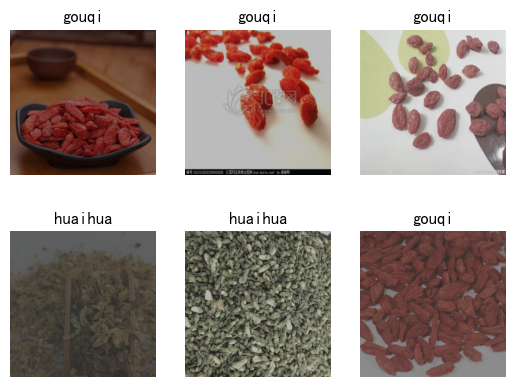

In [8]:
data_iter = next(dataset_train.create_dict_iterator())
images = data_iter["image"].asnumpy()
labels = data_iter["label"].asnumpy()
print(f"Image shape: {images.shape}, Label: {labels}")

plt.figure()
for i in range(6):
        plt.subplot(2, 3, i+1)
        image_trans = np.transpose(images[i], (1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        image_trans = std * image_trans + mean
        image_trans = np.clip(image_trans, 0, 1)
        plt.title(f"{classes[labels[i]]}")
        plt.imshow(image_trans)
        plt.axis("off")
#展示训练集的数据（标签与原图）
plt.show()


## 3. 模型构建

VGGNet 是牛津大学视觉几何组(Visual Geometry Group)提出的模型，该模型在 2014ImageNet 图像分类与定位挑战赛 ILSVRC-2014 中取得在分类任务第二，定位任务第一的优异成绩。VGGNet 突出的贡献是证明了很小的卷积，通过增加网络深度可以有效提高性能。VGG 很好的继承了 Alexnet 的衣钵同时拥有着鲜明的特点。即网络层次较深。 VGGNet 模型有 A-E 五种结构网络，深度分别为 11,11,13,16,19。其中较为典型的网络结构主要有 VGG16 和 VGG19。

VGG16 相比 AlexNet 的一个改进是采用连续的几个 3x3 的卷积核代替 AlexNet 中的较大卷积核（11x11，7x7，5x5）。对于给定的感受野（与输出有关的输入图片的局部大小），采用堆积的小卷积核优于采用大的卷积核，因为多层非线性层可以增加网络深度来保证学习更复杂的模式，而且代价还比较小（参数更少）。 简单来说，在 VGG 中，使用了 3 个 3x3 卷积核来代替 7x7 卷积核，使用了 2 个 3x3 卷积核来代替 5*5 卷积核，这样做的主要目的是在保证具有相同感知野的条件下，提升了网络的深度，在一定程度上提升了神经网络的效果。

所以我们采用 VGG16 网络，mindspore 框架对中草药图片进行分类。

以下是 VGG16 网络的结构展示：

 

<div align=center><img src="https://imgbed.momodel.cn/img/VGG16.png" width="700px"/></div>

### 3.1 构建VGG16网络

In [9]:
class VGG16(nn.Cell):
    def __init__(self):
        super().__init__()
        numClasses = 5
        self.all_sequential = nn.SequentialCell(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, pad_mode="pad"),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 原始模型vgg16输入image大小是224*224，这里使用的数据集输入大小为320*320
            nn.Flatten(),
            nn.Dense(512*10*10, 256),
            nn.ReLU(),
            # nn.Dropout(),
            nn.Dense(256, 256),
            nn.ReLU(),
            # nn.Dropout(),
            nn.Dense(256, numClasses),
        )

    def construct(self, x):
        x = self.all_sequential(x)
        return x


- 模型解析：

    1.   输入 320 x 320 x 3 的图片，经 64 个 3 x 3 的卷积核作两次卷积 + ReLU，卷积后的尺寸变为 320 x 320 x 64
    2.   作 max pooling（最大化池化），池化单元尺寸为 2 x 2（效果为图像尺寸减半），池化后的尺寸变为 160 x 160 x 64
    3.   经 128 个 3 x 3 的卷积核作两次卷积 + ReLU，尺寸变为 160 x 160 x 128
    4.   作 2 x 2 的 max pooling 池化，尺寸变为 80 x 80 x 128
    5.   经 256 个 3 x 3 的卷积核作三次卷积 + ReLU，尺寸变为 80 x 80 x 256
    6.   作 2 x 2 的 max pooling 池化，尺寸变为 40 x 40 x 256
    7.   经 512 个 3 x 3 的卷积核作三次卷积 + ReLU，尺寸变为 40 x 40 x 512
    8.   作 2 x 2 的 max pooling 池化，尺寸变为 20 x 20 x 512
    9.   经 512个 3 x 3 的卷积核作三次卷积 + ReLU，尺寸变为 20 x 20 x 512
    10.  作 2 x 2 的 max pooling 池化，尺寸变为 10 x 10 x 512
    11.  与两层 1 x 1 x 4096，一层 1 x 1 x 1000 进行全连接 + ReLU（共三层）
    12.  通过 softmax 输出 1000 个预测结果(最终会取可能性最大的那个预测结果作为最终预测输出)


下面这个函数主要是用来处理预训练模型的，如果有预训练模型参数需要在训练之前输入，就把 pretrained 设为 True。

此处由于没有预训练模型提供，因此后面在训练的时候设置的是 False。

不需要预训练的话其实这个函数就是：

```
model = VGG16()
```

然后 return 了 model 而已。

In [10]:
from mindspore import load_checkpoint, load_param_into_net

def _vgg16(pretrained: bool = False):
    model = VGG16()
    "VGG16模型"

    #预训练模型的下载网址
#     model_url = "https://download.mindspore.cn/model_zoo/official/cv/vgg/vgg16_ascend_0.5.0_cifar10_official_classification_20200715/vgg16.ckpt"
#     #存储路径
#     model_ckpt = "./LoadPretrainedModel/vgg16_0715.ckpt"

#     if pretrained:
#         download(url=model_url, path=model_ckpt)
#         param_dict = load_checkpoint(model_ckpt)
#         load_param_into_net(model, param_dict)

    return model


## 4. 模型训练

模型训练在 gpu 中完成，训练后模型权重保存在 results 文件夹下的 .ckpt 文件中。

并将每轮的 loss 和 acc 都保存在列表中打印出来，以便后续根据列表做图分析性能。

（下面这个代码块在 train.py 文件中用 gpu 运行）

In [11]:
# 定义VGG16网络，此处不采用预训练，即将pretrained设置为False
vgg16 = _vgg16(pretrained=False)

#param.requires_grad = True表示所有参数都需要求梯度进行更新
for param in vgg16.get_parameters():
    param.requires_grad = True

# 设置训练的轮数和学习率，这里训练的轮数设置为200
num_epochs = 3
#基于余弦衰减函数计算学习率。学习率最小值为0.0001，最大值为0.0005
lr = nn.cosine_decay_lr(min_lr=0.0001, max_lr=0.0005, total_step=step_size_train * num_epochs,
                        step_per_epoch=step_size_train, decay_epoch=num_epochs)

# 定义优化器和损失函数
#Adam优化器
opt = nn.Adam(params=vgg16.trainable_params(), learning_rate=lr)
# 交叉熵损失
loss_fn = nn.CrossEntropyLoss()

#前向传播，计算loss
def forward_fn(inputs, targets):
    logits = vgg16(inputs)
    loss = loss_fn(logits, targets)
    return loss

#计算梯度和loss
grad_fn = ops.value_and_grad(forward_fn, None, opt.parameters)

def train_step(inputs, targets):
    loss, grads = grad_fn(inputs, targets)
    opt(grads)
    return loss

# 实例化模型
model = ms.Model(vgg16, loss_fn, opt, metrics={"Accuracy": nn.Accuracy()})
# 创建迭代器
data_loader_train = dataset_train.create_tuple_iterator(num_epochs=num_epochs)
data_loader_val = dataset_val.create_tuple_iterator(num_epochs=num_epochs)

# 最佳模型存储路径
best_acc = 0
best_ckpt_dir = "/home/jovyan/work/results"
best_ckpt_path = "/home/jovyan/work/results/vgg16-best.ckpt"

Iters = list(i for i in range(num_epochs))
total_loss, total_acc =  [], []

print("Start Training Loop ...")


Start Training Loop ...


In [12]:
# for epoch in range(num_epochs):
#     losses = []
#     vgg16.set_train()

#     # 为每轮训练读入数据
#     for i, (images, labels) in enumerate(data_loader_train):
#         loss = train_step(images, labels)
#         if i % 10 == 0 or i == step_size_train -1:
#             print('Epoch: [%3d/%3d], Steps: [%3d/%3d], Train Loss: [%5.3f]'%(
#                 epoch+1, num_epochs, i+1, step_size_train, loss))
#         losses.append(loss)

#     # 每个epoch结束后，验证准确率
#     acc = model.eval(dataset_val)['Accuracy']
#     total_acc.append(acc)
#     total_loss.append(float(sum(losses)/len(losses)))

#     # 打印中间过程
#     print("-" * 50)
#     print("Epoch: [%3d/%3d], Average Train Loss: [%5.3f], Accuracy: [%5.3f]" % (
#         epoch+1, num_epochs, sum(losses)/len(losses), acc
#     ))
#     print("-" * 50)

#     # 保存模型参数
#     if acc > best_acc:
#         best_acc = acc
#         if not os.path.exists(best_ckpt_dir):
#             os.mkdir(best_ckpt_dir)
#         if os.path.exists(best_ckpt_path):
#             os.chmod(best_ckpt_path, stat.S_IWRITE) #取消文件的只读属性，不然删不了
#             os.remove(best_ckpt_path)
#         ms.save_checkpoint(vgg16, best_ckpt_path)

# print("=" * 80)
# print(f"End of validation the best Accuracy is: {best_acc: 5.3f}, "
#       f"save the best ckpt file in {best_ckpt_path}", flush=True)

# print("Iters:",Iters)
# print("total_loss:",total_loss)
# print("total_acc:",total_acc)


- 加载训练好的模型进行推理

    经过多次测试，模型性能最好时对应的权重参数文件是 vgg16-best_model3.ckpt 文件。

[1 4 1 2 1 0]
Image shape: (6, 3, 320, 320), Label: [1 4 1 2 0 0]
label:dangshen,predict:dangshen
label:jinyinhua,predict:jinyinhua
label:dangshen,predict:dangshen
label:gouqi,predict:gouqi
label:baihe,predict:dangshen
label:baihe,predict:baihe


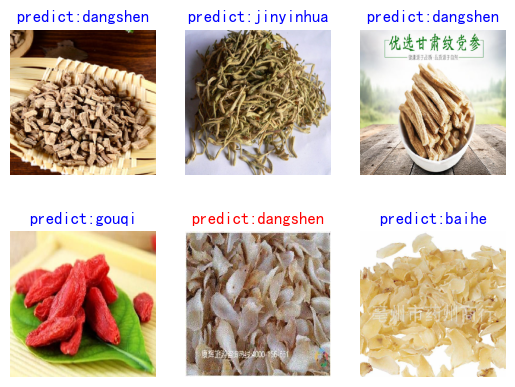

In [13]:
"""
验证和评估效果并且将效果可视化
"""

best_ckpt_path = "/home/jovyan/work/results/vgg16-best_model7.ckpt"

net = _vgg16(pretrained=False)

# 加载模型参数
param_dict = ms.load_checkpoint(best_ckpt_path)
ms.load_param_into_net(net, param_dict)
model = ms.Model(net)

# 加载验证集的数据进行验证
data = next(dataset_val.create_dict_iterator())
images = data["image"].asnumpy()
labels = data["label"].asnumpy()

# 预测图像类别
output = model.predict(ms.Tensor(data['image']))
pred = np.argmax(output.asnumpy(), axis=1)
print(pred)

# 打印分类结果
print(f"Image shape: {images.shape}, Label: {labels}")
for i in range(6):
    print('label:{},predict:{}'.format(classes[labels[i]],classes[pred[i]]))

# 显示图像及图像的预测值
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    # 若预测正确，显示为蓝色；若预测错误，显示为红色
    color = 'blue' if pred[i] == labels[i] else 'red'
    plt.title('predict:{}'.format(classes[pred[i]]), color=color)
    picture_show = np.transpose(images[i], (1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    picture_show = std * picture_show + mean
    picture_show = np.clip(picture_show, 0, 1)
    plt.imshow(picture_show)
    plt.axis('off')

plt.show()


- 若预测正确，显示为蓝色；若预测错误，显示为红色

    1. 可以看到验证集的 6 张图片中，2 张预测正确显示蓝色，4 张预测错误显示红色    
    2. 第二张图片将 baihe 预测为 gouqi
    3. 第三张图片将 gouqi 预测为 jinyinhua
    4. 第四张图片将 gouqi 预测为 jinyinhua
    5. 第五张图片将 baihe 预测为 gouqi

- 模型正确率不是很高，因为相对模型复杂度，数据集有点小，若用大数据集训练，正确率会有较高的提升。

## 5. 模型评估

### 5.1 可视化每轮损失和正确率的变化

保存训练时每轮的损失和正确率放入列表中，在 gpu 训练完成后输出列表。  
这里将 Iters，total_loss，total_acc 的输出值复制过来，分别以 total_loss 和 total_acc 为纵轴，Iters 为横轴，做出模型训练时的图像。

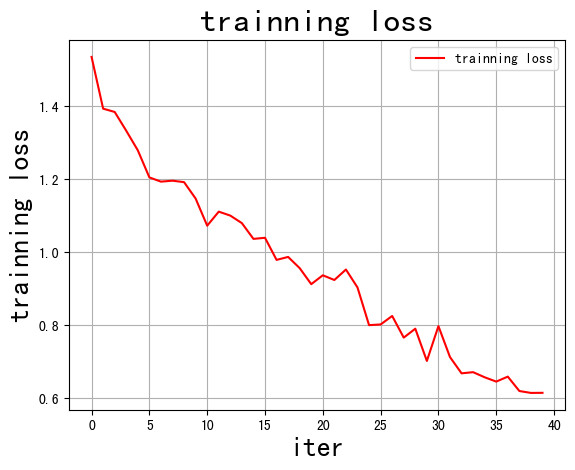

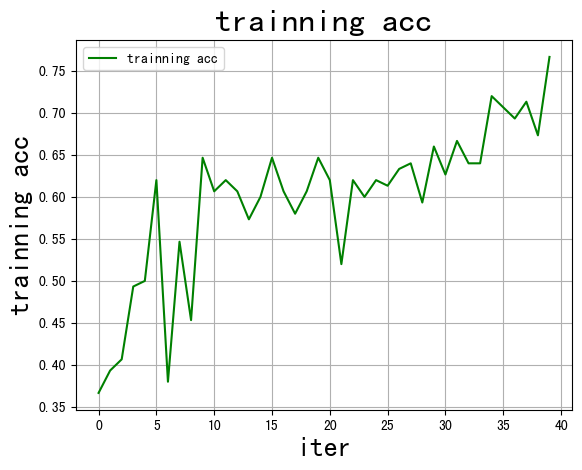

In [14]:
def draw_process(title,color,iters,data,label):
    plt.title(title, fontsize=24)
    plt.xlabel("iter", fontsize=20)
    plt.ylabel(label, fontsize=20)
    plt.plot(iters,data,color=color,label=label)
    plt.legend()
    plt.grid()
    plt.show()

# model_3
total_loss = [1.5358283519744873, 1.394041895866394, 1.3849847316741943, 1.3334367275238037, 1.279801607131958, 1.2056164741516113, 1.1940255165100098, 1.1966158151626587, 1.1926437616348267, 1.147674798965454, 1.0733181238174438, 1.111806035041809, 1.1009397506713867, 1.0803306102752686, 1.0371557474136353, 1.040122151374817, 0.9795835614204407, 0.9876789450645447, 0.9569410681724548, 0.9130285382270813, 0.9373617768287659, 0.9244836568832397, 0.9531596899032593, 0.9040157794952393, 0.800735592842102, 0.8025913834571838, 0.8258737325668335, 0.7665766477584839, 0.7909490466117859, 0.7026452422142029, 0.7980622053146362, 0.7132045030593872, 0.6686837077140808, 0.6718282699584961, 0.6578366756439209, 0.6460011601448059, 0.6596536040306091, 0.62019282579422, 0.6149743795394897, 0.6152564287185669]
total_acc = [0.36666666666666664, 0.3933333333333333, 0.4066666666666667, 0.49333333333333335, 0.5, 0.62, 0.38, 0.5466666666666666, 0.4533333333333333, 0.6466666666666666, 0.6066666666666667, 0.62, 0.6066666666666667, 0.5733333333333334, 0.6, 0.6466666666666666, 0.6066666666666667, 0.58, 0.6066666666666667, 0.6466666666666666, 0.62, 0.52, 0.62, 0.6, 0.62, 0.6133333333333333, 0.6333333333333333, 0.64, 0.5933333333333334, 0.66, 0.6266666666666667, 0.6666666666666666, 0.64, 0.64, 0.72, 0.7066666666666667, 0.6933333333333334, 0.7133333333333334, 0.6733333333333333, 0.7666666666666667]
Iters = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

draw_process("trainning loss","red",Iters,total_loss,"trainning loss")
draw_process("trainning acc","green",Iters,total_acc,"trainning acc")


### 5.2 对验证集数据进行验证

加载训练好的模型权重参数，对验证集数据进行验证，将验证集 150 张图像的预测结果全部存储在列表 y_pred 中，并输出相对应的标签 y_ture。 

In [15]:
y_true = []
y_pred = []

# 加载验证集的数据进行验证
for i, (images, labels) in enumerate(data_loader_val):
    for label in labels.asnumpy():
        y_true.append(label)

    # 预测图像类别
    output = model.predict(ms.Tensor(images))
    preds = np.argmax(output.asnumpy(), axis=1)

    for pred in preds:
        y_pred.append(pred)

    print("第{}轮的lable:{},preds:{}".format(i,labels.asnumpy(),preds))

# 打印结果
print("y_true:",y_true)
print("y_pred:",y_pred)


[WARNING] MD(319,7fee41de8700,python):2025-08-08-14:42:31.490.748 [mindspore/ccsrc/minddata/dataset/engine/datasetops/batch_op.cc:116] operator()] Memory consumption is more than 90.004%, which may cause OOM. Please reduce num_parallel_workers size / optimize 'per_batch_map' function / other python data preprocess function to reduce memory usage.


第0轮的lable:[2 3 1 1 4 0],preds:[2 4 1 1 4 0]
第1轮的lable:[0 2 2 4 4 3],preds:[0 2 2 4 4 3]
第2轮的lable:[3 3 0 4 1 2],preds:[3 4 0 4 1 2]
第3轮的lable:[2 3 0 2 1 0],preds:[0 3 0 2 1 0]
第4轮的lable:[4 1 4 0 4 2],preds:[4 4 4 1 1 2]
第5轮的lable:[1 3 4 3 1 0],preds:[0 0 4 4 1 0]
第6轮的lable:[2 0 0 0 2 0],preds:[2 0 0 0 2 0]
第7轮的lable:[1 0 2 0 2 3],preds:[1 0 2 1 2 3]
第8轮的lable:[2 2 4 1 4 2],preds:[2 2 4 1 4 2]
第9轮的lable:[4 4 0 0 1 2],preds:[4 4 1 0 1 2]
第10轮的lable:[0 3 1 0 4 1],preds:[0 3 3 0 4 1]
第11轮的lable:[1 1 1 2 1 1],preds:[1 1 1 2 1 1]
第12轮的lable:[4 1 3 1 4 2],preds:[3 1 1 1 3 2]
第13轮的lable:[4 3 3 3 2 0],preds:[4 4 3 3 2 1]
第14轮的lable:[4 4 3 0 2 1],preds:[4 4 1 1 2 1]
第15轮的lable:[2 0 1 3 4 0],preds:[2 0 0 3 4 0]
第16轮的lable:[3 4 3 1 4 3],preds:[3 4 4 1 4 4]
第17轮的lable:[3 2 1 0 3 3],preds:[4 2 1 0 3 1]
第18轮的lable:[1 3 0 4 3 0],preds:[1 3 0 4 3 1]
第19轮的lable:[2 2 3 0 1 2],preds:[2 2 4 0 1 2]
第20轮的lable:[4 2 2 1 3 2],preds:[4 2 2 1 4 2]
第21轮的lable:[0 1 3 3 0 4],preds:[0 1 3 4 0 4]
第22轮的lable:[2 3 4 2 

y_pred 和 y_ture 在 gpu 训练时输出，输出结果如下：

In [16]:
y_true = [0, 4, 4, 0, 4, 1, 1, 0, 4, 1, 0, 1, 0, 4, 3, 0, 3, 2, 0, 2, 2, 0, 0, 1, 2, 2, 2, 4, 0, 4, 3, 0, 0, 4, 1, 2, 4, 4, 0, 1, 3, 4, 1, 2, 3, 2, 0, 0, 4, 1, 1, 2, 3, 3, 2, 3, 1, 2, 2, 4, 4, 3, 3, 4, 3, 0, 1, 3, 1, 4, 4, 1, 4, 1, 4, 3, 2, 3, 0, 1, 0, 3, 2, 3, 2, 2, 0, 3, 4, 1, 1, 0, 4, 0, 0, 2, 4, 2, 0, 2, 2, 3, 2, 3, 3, 3, 4, 3, 1, 0, 4, 1, 0, 1, 2, 1, 2, 3, 4, 3, 1, 2, 4, 1, 3, 1, 1, 2, 2, 0, 3, 2, 0, 3, 0, 0, 4, 4, 1, 0, 3, 2, 2, 1, 1, 4, 3, 3, 1, 4]
y_pred = [0, 4, 4, 0, 4, 0, 0, 1, 4, 0, 4, 3, 0, 4, 3, 0, 1, 2, 0, 2, 2, 0, 2, 1, 2, 2, 2, 4, 0, 4, 4, 0, 0, 4, 1, 2, 4, 4, 0, 0, 3, 4, 1, 2, 3, 2, 0, 0, 4, 1, 0, 2, 3, 3, 2, 3, 0, 2, 2, 4, 3, 3, 1, 4, 3, 0, 0, 3, 1, 0, 4, 1, 4, 0, 3, 3, 2, 3, 0, 1, 0, 3, 2, 3, 2, 2, 1, 4, 4, 1, 1, 0, 4, 0, 0, 2, 4, 2, 0, 2, 2, 4, 2, 3, 4, 1, 3, 3, 0, 0, 4, 0, 0, 1, 2, 0, 2, 3, 4, 3, 0, 2, 3, 1, 3, 1, 1, 2, 2, 0, 3, 2, 0, 4, 0, 0, 3, 4, 1, 0, 3, 2, 2, 0, 1, 4, 4, 4, 0, 4]


### 5.3 混淆矩阵

在机器学习领域，混淆矩阵又称为可能性表格或是错误矩阵，它是一种特定的矩阵用来呈现算法性能的可视化效果。  
*   查准率：在模型预测为正类的所有结果中，模型预测正确的比重。
*   召回率：在真实值为正类的所有结果中，模型预测正确的比重。
*   F—score 是可以综合考虑查准率和召回率的调和值。  
F1—score 代表查准率和召回率权重相同。
*   准确率：预测正确的样本占所有样本的比率。

以下输出验证集的混淆矩阵和对应的热力图，以及查准率和召回率。  
**混淆矩阵每一列代表预测值，每一行代表的是实际的类别。**  
热力图颜色越深，说明分错的越少。

混淆矩阵：
 [[26  2  1  0  1]
 [14 15  0  1  0]
 [ 0  0 30  0  0]
 [ 0  3  0 20  7]
 [ 1  0  0  5 24]]


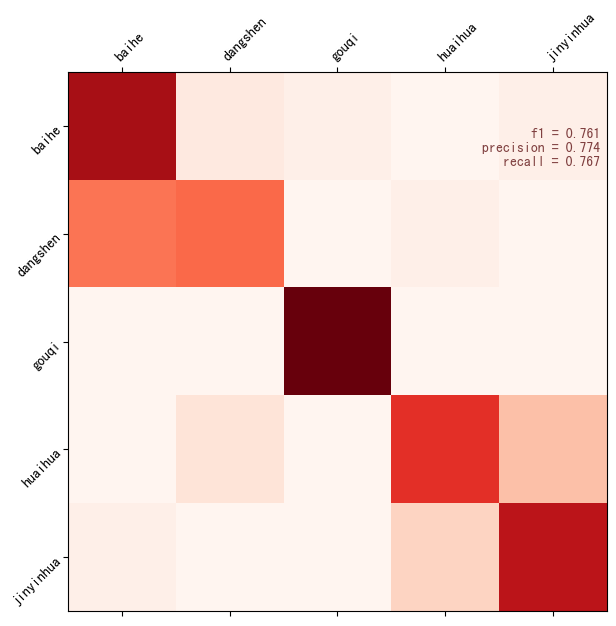

f1 score: 0.761, precision: 0.774, recall: 0.767



In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

def display_confusion_matrix(cmat, score, precision, recall):
    plt.figure(figsize=(7,7))
    ax = plt.gca() # 获取坐标轴信息
    ax.matshow(cmat, cmap='Reds')
    ax.set_xticks(range(len(classes))) # 设置刻度
    ax.set_xticklabels(classes, fontdict={'fontsize': 10})
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")
    ax.set_yticks(range(len(classes))) # 设置刻度
    ax.set_yticklabels(classes, fontdict={'fontsize': 10})
    plt.setp(ax.get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    titlestring = ""
    if score is not None:
        titlestring += 'f1 = {:.3f} '.format(score)
    if precision is not None:
        titlestring += '\nprecision = {:.3f} '.format(precision)
    if recall is not None:
        titlestring += '\nrecall = {:.3f} '.format(recall)
    if len(titlestring) > 0:
        ax.text(4.5, 0.01, titlestring, fontdict={'fontsize': 10, 'horizontalalignment':'right', 'verticalalignment':'top', 'color':'#804040'})
    plt.show()

cmat = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
print("混淆矩阵：\n",cmat)
score = f1_score(y_true, y_pred, labels=range(len(classes)), average='macro')
precision = precision_score(y_true, y_pred, labels=range(len(classes)), average='macro')
recall = recall_score(y_true, y_pred, labels=range(len(classes)), average='macro')
display_confusion_matrix(cmat, score, precision, recall)
print('f1 score: {:.3f}, precision: {:.3f}, recall: {:.3f}'.format(score, precision, recall)); print()


通过观察混淆矩阵可以发现，dangshen（党参）被错误分类的样本最多，有一半都被错误分类。  
在这一半错分的样本中，几乎都被错误分类为 baihe（百合）。

- 将某一类样本作为正样本，其他四类作为负样本，可分别得到五个类别对应的查准率、召回率和 F1。

    这种求法和根据混淆矩阵求查准率、召回率和 F1 的结果是相同的。

    具体来说：

    *   查准率=混淆矩阵主对角线上的值/该值所在列的和
    *   召回率=混淆矩阵主对角线上的值/该值所在行的和
    *   准确率=混淆矩阵主对角线上值的和/总样本数

In [18]:
class Myreport:
    def __init__(self):
        self.__confusion = None

    def __statistics_confusion(self,y_true,y_predict): # 计算混淆矩阵
        self.__confusion = np.zeros((5, 5))
        for i in range(len(y_true)):
            self.__confusion[y_predict[i]][y_true[i]] += 1

    def __cal_Acc(self): # 计算准确率
        return np.sum(self.__confusion.diagonal()) / np.sum(self.__confusion)

    def __cal_Pc(self): # 计算查准率
        return self.__confusion.diagonal() / np.sum(self.__confusion, axis=1)

    def __cal_Rc(self): # 计算召回率
        return self.__confusion.diagonal() / np.sum(self.__confusion, axis=0)

    def __cal_F1score(self,PC,RC): # 计算F1
        return 2 * np.multiply(PC, RC) / (PC + RC)

    def report(self,y_true,y_predict,classNames):
        self.__statistics_confusion(y_true,y_predict)
        Acc = self.__cal_Acc()
        Pc = self.__cal_Pc()
        Rc = self.__cal_Rc()
        F1score = self.__cal_F1score(Pc,Rc)
        str = "Class Name\t\tprecision\trecall\t\tf1-score\n"
        for i in range(len(classNames)):
           str += f"{classNames[i]}   \t\t{format(Pc[i],'.2f')}   \t\t{format(Rc[i],'.2f')}" \
                  f"   \t\t{format(F1score[i],'.2f')}\n"
        str += f"accuracy is {format(Acc,'.2f')}"
        return str


myreport = Myreport()
print(myreport.report(y_true=y_true,y_predict=y_pred,classNames=classes))


Class Name		precision	recall		f1-score
baihe   		0.63   		0.87   		0.73
dangshen   		0.75   		0.50   		0.60
gouqi   		0.97   		1.00   		0.98
huaihua   		0.77   		0.67   		0.71
jinyinhua   		0.75   		0.80   		0.77
accuracy is 0.77


-  根据每个类别相应的查准率、召回率和 F1，可以更加直观和具体地分析出每种类别的分类情况。

    *   baihe 的召回率比较高，但精确率比较低，这是因为有几乎一半的 dangshen 被错误分类为了 baihe，相应地，这也使得 dangshen 的召回率特别低。
    *   gouqi 的精确率、召回率和 F1 都特别高，是五个类别中分类最好的。
    *   huaihua 的精确率不高，这是因为有小部分的 jinyinhua 错误分类为了 huaihua，这也同时导致了 jinyinhua 的召回率不高。
    *   huaihua 的召回率也比较低，这是因为有三分之一的样本被错误分类，且大部分被错误分类为 jinyinhua，相应地导致了jinyinhua 的精确率也不高。


## 6. 模型改进方向

模型在验证集上的准确率为 0.77。

**经过多次实验发现，增大训练轮数对模型准确率并没有很大的提高。**

### 以下是提高模型性能的一些措施：
*   增大数据集，大样本有助于模型学习更多的知识，如各类样本之间的差别  
*   增加 dangshen 样本比例，加强 dangshen 的学习
*   强化模型对 huaihua 和 jinyinhua 的区分
*   增大 batchsize  
*   可以引入集成学习，同时训练出多个模型，对他们的结果加权求和，得到最终结果
*   增加错分样本的权重，强化对错分样本的训练